In [1]:
from transformers import GPT2LMHeadModel

c:\Users\benha\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

c:\Users\benha\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\benha\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6069.73it/s]


transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [3]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

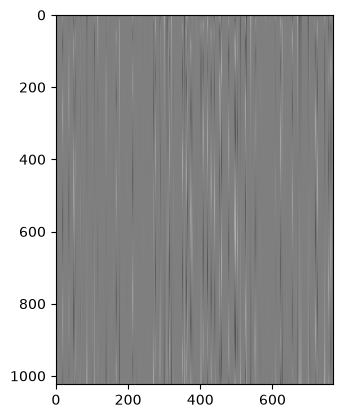

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

w = sd_hf["transformer.wpe.weight"]
w_centered = w - w.mean(dim=0)          # subtract the per-column average
plt.imshow(w_centered, cmap="gray", vmin=-w_centered.abs().max()/4, vmax=w_centered.abs().max()/4)

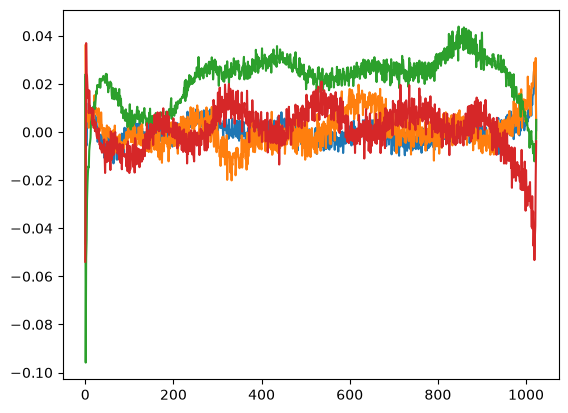

In [53]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])
# plt.plot(sd_hf["transformer.wpe.weight"][:, 300]) # this one is on a totally different scale
# plt.plot(sd_hf["transformer.wpe.weight"][:, 359])
# plt.plot(sd_hf["transformer.wpe.weight"][:, 413])
plt.plot(sd_hf["transformer.wpe.weight"][:, 450])

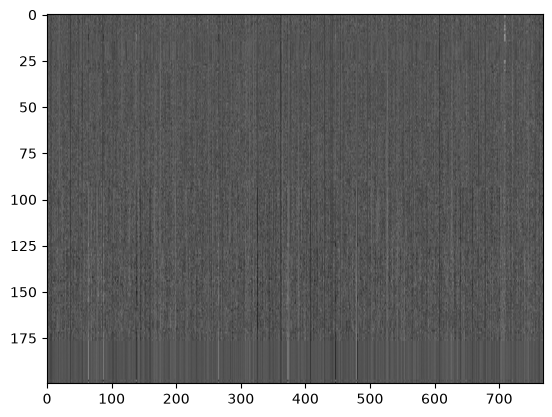

Text(0, 0.5, '768 dim L2 vector length')

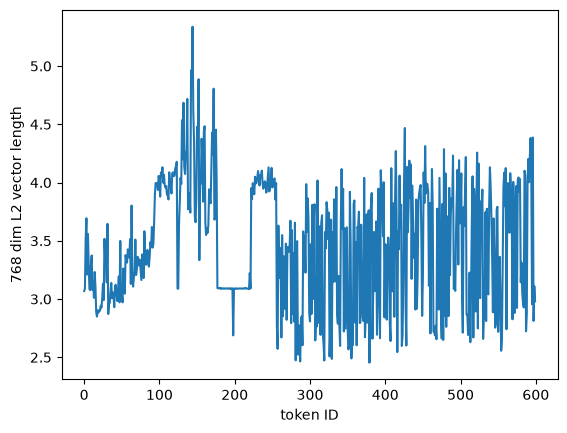

In [30]:
## visualize the wte token to embedding lookup table (these are learned weights)

wte = sd_hf["transformer.wte.weight"]   # [50257, 768]

plt.imshow(wte[:200], cmap="gray", aspect="auto") 
plt.show()

# L2 norm (vector length) of each token embedding for the first 600 token IDs
norms = wte[:600].norm(dim=1)   # [600, 768] -> [600]; dim=1 collapses the 768 embedding dims

# x-axis: token ID, y-axis: embedding norm (look for level shifts, e.g. byte tokens vs. merged tokens)
plt.plot(norms)
plt.xlabel("token ID")
plt.ylabel("768 dim L2 vector length")

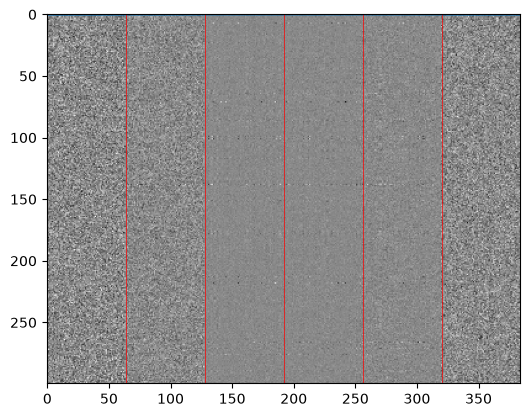

In [ ]:
head_size = 64
x_axis = head_size * 6

plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:x_axis], cmap="gray")
# From the grayscale plot defined above I can distinctly see columns about every 64 on the X axis which happens to be the same size as each attention head in the multi-headed attention

# The logic below overlays red lines every 64 i think this shows that each attention head learns on a different scale. However if you look at the end of the GPT (transformer 11) this graph will look uniform.
w = sd_hf["transformer.h.1.attn.c_attn.weight"]
std_per_col = w[:, :x_axis].std(dim=0)          # Q part only
plt.plot(std_per_col)
for i in range(0, x_axis, head_size): plt.axvline(i, color="r", lw=0.5)


## transformer for reference
# transformer.h.0.ln_1.weight        [768]
# transformer.h.0.ln_1.bias          [768]
# transformer.h.0.attn.c_attn.weight [768, 2304]   <<-- we are here (Q|K|V concatenated)
# transformer.h.0.attn.c_attn.bias   [2304]
#     -> split into 12 heads of 64, QK^T / sqrt(64), causal mask
#     -> softmax  (no weights, code only)
#     -> multiply by V, merge heads
# transformer.h.0.attn.c_proj.weight [768, 768]
# transformer.h.0.attn.c_proj.bias   [768]
#     -> + residual
# transformer.h.0.ln_2.weight        [768]
# transformer.h.0.ln_2.bias          [768]
# transformer.h.0.mlp.c_fc.weight    [768, 3072]
# transformer.h.0.mlp.c_fc.bias      [3072]
#     -> GELU  (nonlinearity, no weights, code only)
# transformer.h.0.mlp.c_proj.weight  [3072, 768]
# transformer.h.0.mlp.c_proj.bias    [768]
#     -> + residual

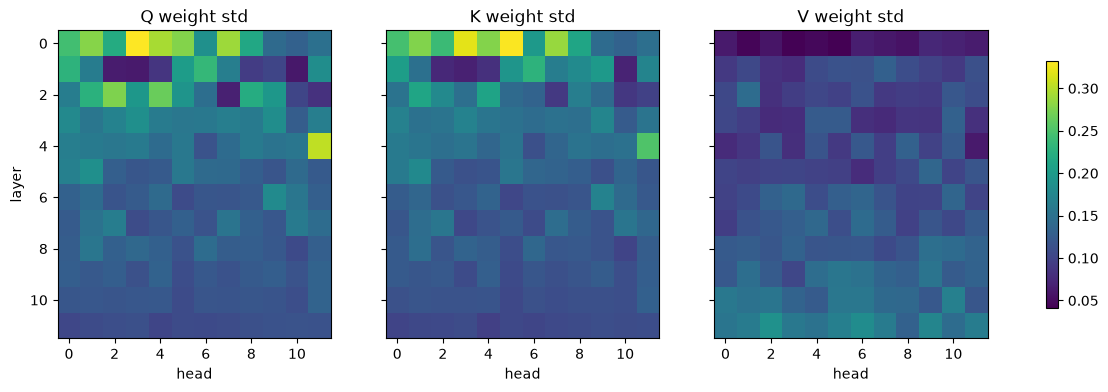

In [ ]:
# The plot below compares the QK and V matrices: standard deviation=color y axis=layer x axis=attention head
# we take std of all values in each [768,64] head
# To me it makes sense that the Q and K matrices match very closely becuase we use Q to search for a matching K which will return a V

import torch
import matplotlib.pyplot as plt

names = ["Q", "K", "V"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# one shared color scale so Q, K, V are directly comparable
all_stds = []
for L in range(12):
    w = sd_hf[f"transformer.h.{L}.attn.c_attn.weight"]            # [768, 2304]
    # split columns into Q|K|V, then into 12 heads of 64; std per head
    per_head = torch.stack([
        w[:, i*768:(i+1)*768].reshape(768, 12, 64).std(dim=(0, 2))
        for i in range(3)
    ])                                                            # [3, 12]
    all_stds.append(per_head)
stds = torch.stack(all_stds)                                      # [layer=12, qkv=3, head=12]

vmin, vmax = stds.min().item(), stds.max().item()
for i, ax in enumerate(axes):
    im = ax.imshow(stds[:, i, :], aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title(f"{names[i]} weight std")
    ax.set_xlabel("head")
axes[0].set_ylabel("layer")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [66]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7913.88it/s]
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KeyboardInterrupt: 

In [33]:
# let's instead sample manually
import torch
from torch.nn import functional as F

model = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
model.eval()
model.to('cuda')
torch.manual_seed(42)
torch.cuda.manual_seed(42)
tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11] # "Hello, I'm a language model,"
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(5, 1) # (5, 8)
x = tokens.to('cuda')

# generate!
while x.size(1) < 30: # max_length=30
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x)[0] # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        # note: multinomial does not demand the input to sum to 1
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

# print the generated text
import tiktoken
enc = tiktoken.get_encoding('gpt2')
for i in range(5):
    tokens = x[i, :30].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8316.35it/s]


AssertionError: Torch not compiled with CUDA enabled

In [ ]:
# tiny shakespeare dataset
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r') as f:
    text = f.read()
data = text[:1000] # first 1,000 characters
print(data[:100])

In [ ]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

In [ ]:
import torch
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

In [ ]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

In [ ]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

In [ ]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

In [ ]:

# standard deviation grows inside the residual stream
x = torch.zeros(768)
n = 100 # e.g. 100 layers
for i in range(n):
    x += n**-0.5 * torch.randn(768)

print(x.std())

In [ ]:
import torch

# super simple little MLP
net = torch.nn.Sequential(
    torch.nn.Linear(16, 32),
    torch.nn.GELU(),
    torch.nn.Linear(32, 1)
)
torch.random.manual_seed(42)
x = torch.randn(4, 16)
y = torch.randn(4, 1)
net.zero_grad()
yhat = net(x)
loss = torch.nn.functional.mse_loss(yhat, y)
loss.backward()
print(net[0].weight.grad.view(-1)[:10])

# the loss objective here is (due to readuction='mean')
# L = 1/4 * [
#            (y[0] - yhat[0])**2 +
#            (y[1] - yhat[1])**2 +
#            (y[2] - yhat[2])**2 +
#            (y[3] - yhat[3])**2
#           ]
# NOTE: 1/4!

In [ ]:
# now let's do it with grad_accum_steps of 4, and B=1
# the loss objective here is different because
# accumulation in gradient <---> SUM in loss
# i.e. we instead get:
# L0 = 1/4(y[0] - yhat[0])**2
# L1 = 1/4(y[1] - yhat[1])**2
# L2 = 1/4(y[2] - yhat[2])**2
# L3 = 1/4(y[3] - yhat[3])**2
# L = L0 + L1 + L2 + L3
# NOTE: the "normalizer" of 1/4 is lost
net.zero_grad()
for i in range(4):
    yhat = net(x[i])
    loss = torch.nn.functional.mse_loss(yhat, y[i])
    loss = loss / 4 # <-- have to add back the "normalizer"!
    loss.backward()
print(net[0].weight.grad.view(-1)[:10])


In [ ]:
# parse and visualize the logfile
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sz = "124M"

loss_baseline = {
    "124M": 3.2924,
}[sz]
hella2_baseline = { # HellaSwag for GPT-2
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]
hella3_baseline = { # HellaSwag for GPT-3
    "124M": 0.337,
    "350M": 0.436,
    "774M": 0.510,
    "1558M": 0.547,
}[sz]

# load the log file
with open("log124M_40B/log.txt", "r") as f:
    lines = f.readlines()

# parse the individual lines, group by stream (train,val,hella)
streams = {}
for line in lines:
    step, stream, val = line.strip().split()
    if stream not in streams:
        streams[stream] = {}
    streams[stream][int(step)] = float(val)

# convert each stream from {step: val} to (steps[], vals[])
# so it's easier for plotting
streams_xy = {}
for k, v in streams.items():
    # get all (step, val) items, sort them
    xy = sorted(list(v.items()))
    # unpack the list of tuples to tuple of lists
    streams_xy[k] = list(zip(*xy))

# create figure
plt.figure(figsize=(16, 6))

# Panel 1: losses: both train and val
plt.subplot(121)
xs, ys = streams_xy["train"] # training loss
ys = np.array(ys)
plt.plot(xs, ys, label=f'nanogpt ({sz}) train loss')
print("Min Train Loss:", min(ys))
xs, ys = streams_xy["val"] # validation loss
plt.plot(xs, ys, label=f'nanogpt ({sz}) val loss')
# horizontal line at GPT-2 baseline
if loss_baseline is not None:
    plt.axhline(y=loss_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale('log')
plt.ylim(top=4.0)
plt.legend()
plt.title("Loss")
print("Min Validation Loss:", min(ys))

# Panel 2: HellaSwag eval
plt.subplot(122)
xs, ys = streams_xy["hella"] # HellaSwag eval
ys = np.array(ys)
plt.plot(xs, ys, label=f"nanogpt ({sz})")
# horizontal line at GPT-2 baseline
if hella2_baseline:
    plt.axhline(y=hella2_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint")
if hella3_baseline:
    plt.axhline(y=hella3_baseline, color='g', linestyle='--', label=f"OpenAI GPT-3 ({sz}) checkpoint")
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.legend()
plt.title("HellaSwag eval")
print("Max Hellaswag eval:", max(ys))